In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import geopandas as gpd
import xarray as xr
import pandas as pd
from netCDF4 import Dataset
import dask
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl
from shapely.geometry import Polygon, MultiPolygon

# Shading avec dhdt

In [2]:
# Shape File regions
shp = gpd.read_file('/bettik/PROJECTS/pr-regional-climate/bricej/HIMAP_grouped_regions/himap_grouped_regions.shp')

In [3]:
#dhdt 
dhdt = pd.read_csv('/bettik/PROJECTS/pr-regional-climate/bricej/paper/dhdt_2000-2019_HIMAPgrouped_regions.csv')

In [4]:
# Merge avec le GeoDataFrame
shp = shp.merge(
    dhdt,
    left_on="Primary_ID",
    right_on="region",
    how="left"
)

In [5]:
short_name = ['B','CH','HK','TP','Ka','Ku','N','P','PA','SL','TS']

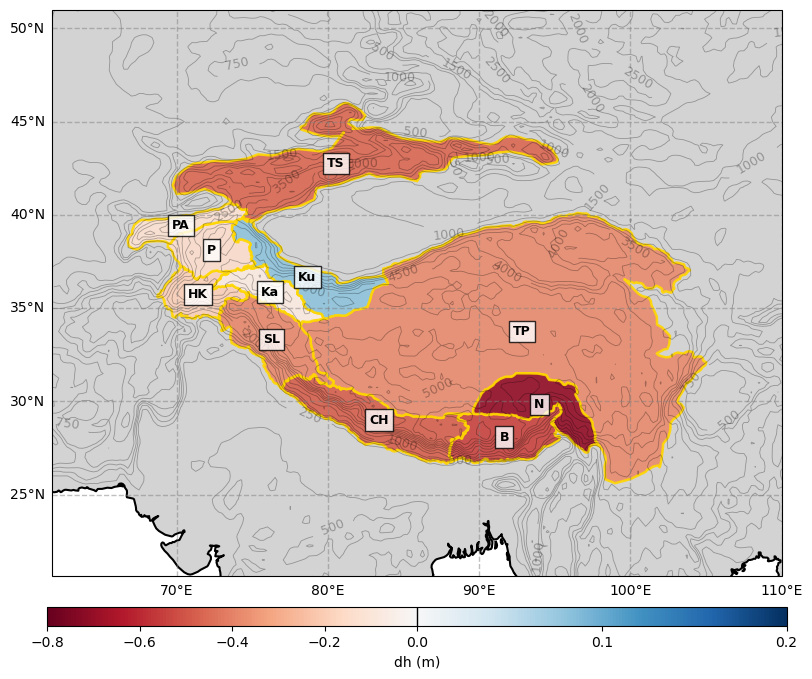

In [6]:
# Figure
fig, ax = plt.subplots(
    figsize=(12, 8),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Normalisation centrée sur 0
norm = mcolors.TwoSlopeNorm(
    vmin=-0.8,
    vcenter=0,
    vmax=0.2
)

# Plot des régions avec shading selon dhdt
shp.plot(
    column="dhdt",
    cmap="RdBu",   # bleu = perte, rouge = gain
    norm=norm,
    ax=ax,
    edgecolor="gold",
    linewidth=1.8,
    alpha=0.9,
    legend=False,
)

# Borders
ax.coastlines(linewidth=1.5)
#ax.add_feature(cfeature.BORDERS, linewidth=1)
ax.add_feature(cfeature.LAND, facecolor="lightgrey")

# Courbes de niveau
elev = xr.open_dataset(
    '/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc'
)['elevation']

SH = ax.contour(
    elev.longitude,
    elev.latitude,
    elev,
    levels=[250,500,750,1000,1500,2000,2500,3000,
            3500,4000,4500,5000,5500,6000,6500,7000],
    colors="black",
    linewidths=0.6,
    alpha=0.3,
    transform=ccrs.PlateCarree()
)

ax.clabel(SH, inline=True, fontsize=9, fmt="%d")


# Labels des régions
for idx, row in shp.iterrows():

    centroid = row.geometry.centroid
    ax.text(
       centroid.x,
        centroid.y,
        f"{short_name[idx]}",
        fontsize=9,
        fontweight='bold',
        ha='center',
        va='center',
        color='black',
        transform=ccrs.PlateCarree(),
        zorder=5,
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3)
    )
    #f"{row['Primary_ID']}\n{row['dhdt']:.2f}"


# Extent
bounds = shp.total_bounds

ax.set_extent(
    [bounds[0]-5, bounds[2]+5,
     bounds[1]-5, bounds[3]+5],
    crs=ccrs.PlateCarree()
)

# Grille
gl = ax.gridlines(
    draw_labels=True,
    linewidth=1,
    color='gray',
    alpha=0.5,
    linestyle='--'
)

gl.top_labels = False
gl.right_labels = False

# colorbar
sm = mpl.cm.ScalarMappable(
    cmap="RdBu",
    norm=mcolors.TwoSlopeNorm(
        vmin=-0.8,
        vcenter=0,
        vmax=0.2
    )
)
sm._A = []
cbar = plt.colorbar(
    sm,
    ax=ax,
    orientation='horizontal',
    shrink=0.9,      # taille globale (largeur)
    pad=0.05,        # distance à la figure (↓ plus petit = plus proche)
    fraction=0.03,   # épaisseur de la colorbar (↓ plus fin)
    aspect=40        # longueur vs épaisseur (↑ = plus long et fin)
)
cbar.set_label("dh (m)")
cbar.set_ticks([-0.8, -0.6, -0.4, -0.2, 0, 0.1, 0.2])
cbar.ax.axvline(0, color='black', linewidth=1) # forcer une meilleure perception de 0

plt.show()

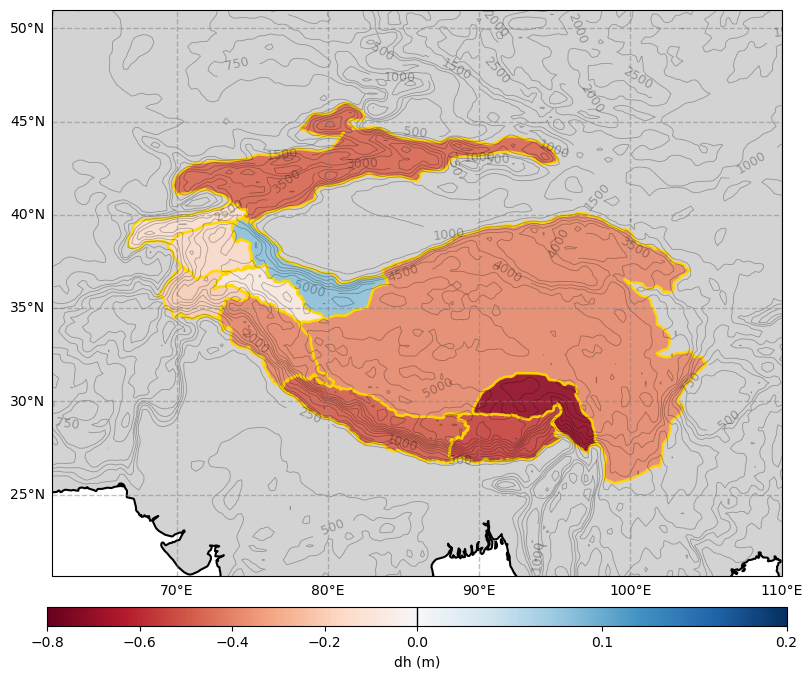

In [7]:
# Figure
fig, ax = plt.subplots(
    figsize=(12, 8),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Normalisation centrée sur 0
norm = mcolors.TwoSlopeNorm(
    vmin=-0.8,
    vcenter=0,
    vmax=0.2
)

# Plot des régions avec shading selon dhdt
shp.plot(
    column="dhdt",
    cmap="RdBu",   # bleu = perte, rouge = gain
    norm=norm,
    ax=ax,
    edgecolor="gold",
    linewidth=1.8,
    alpha=0.9,
    legend=False,
)

# Borders
ax.coastlines(linewidth=1.5)
#ax.add_feature(cfeature.BORDERS, linewidth=1)
ax.add_feature(cfeature.LAND, facecolor="lightgrey")

# Courbes de niveau
elev = xr.open_dataset(
    '/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc'
)['elevation']

SH = ax.contour(
    elev.longitude,
    elev.latitude,
    elev,
    levels=[250,500,750,1000,1500,2000,2500,3000,
            3500,4000,4500,5000,5500,6000,6500,7000],
    colors="black",
    linewidths=0.6,
    alpha=0.3,
    transform=ccrs.PlateCarree()
)

ax.clabel(SH, inline=True, fontsize=9, fmt="%d")


# Extent
bounds = shp.total_bounds

ax.set_extent(
    [bounds[0]-5, bounds[2]+5,
     bounds[1]-5, bounds[3]+5],
    crs=ccrs.PlateCarree()
)

# Grille
gl = ax.gridlines(
    draw_labels=True,
    linewidth=1,
    color='gray',
    alpha=0.5,
    linestyle='--'
)

gl.top_labels = False
gl.right_labels = False

# colorbar
sm = mpl.cm.ScalarMappable(
    cmap="RdBu",
    norm=mcolors.TwoSlopeNorm(
        vmin=-0.8,
        vcenter=0,
        vmax=0.2
    )
)
sm._A = []
cbar = plt.colorbar(
    sm,
    ax=ax,
    orientation='horizontal',
    shrink=0.9,      # taille globale (largeur)
    pad=0.05,        # distance à la figure (↓ plus petit = plus proche)
    fraction=0.03,   # épaisseur de la colorbar (↓ plus fin)
    aspect=40        # longueur vs épaisseur (↑ = plus long et fin)
)
cbar.set_label("dh (m)")
cbar.set_ticks([-0.8, -0.6, -0.4, -0.2, 0, 0.1, 0.2])
cbar.ax.axvline(0, color='black', linewidth=1) # forcer une meilleure perception de 0

plt.show()